<br>


# 基于 PyTorch 构建卷积神经网络 CNN

<br>

## 0. 概述

<br>

<font color=black size=3 face=雅黑>　　在前面的实验内容中，我们已经学习了 PyTorch 的基本数据类型 tensor 及其相关操作。下面，我们就正式开始学习如何基于 PyTorch 读入和预处理处理数据集，搭建一个神经网络进行训练和测试。
    
<br>

<font color=black size=3 face=雅黑>　　总体来讲，我们在这部分实验中要进行的操作包括以下几点：

<font color=black size=3 face=雅黑>　　1) 　读取和处理数据集
    
<font color=black size=3 face=雅黑>　　2) 　定义一个包含可训练参数的神经网络
    
<font color=black size=3 face=雅黑>　　3) 　从数据集中取出一个批次 (batch) 的样本传递给神经网络

<font color=black size=3 face=雅黑>　　4) 　通过神经网络处理输入样本

<font color=black size=3 face=雅黑>　　5) 　计算损失 (loss)

<font color=black size=3 face=雅黑>　　6) 　反向传播计算偏导

<font color=black size=3 face=雅黑>　　7) 　更新网络的参数 (一个简单的更新方法：weight = weight - learning_rate *gradient)
    
<font color=black size=3 face=雅黑>　　8) 　重复 3) 到 7) 步，不断调整网络参数

<br>

## 1. 导入 PyTorch 及其他相关库

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

<font color=black size=3 face=雅黑>查看 PyTorch 版本，是否可以使用 GPU，及 CUDA 的版本。

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.9.0+cu126
True
12.6


## 2. 准备数据集 (Data Preparation)

<br>

In [3]:
batch_size = 80  # 设置训练集和测试集的 batch size，即每批次将参与运算的样本数

train_set = torchvision.datasets.CIFAR10(root='./dataset_cifar10', train=True, download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(), 
                                            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))

###################### 请将 test_set 的对应代码粘贴在此 #########################

test_set = torchvision.datasets.CIFAR10(root='./dataset_cifar10', train=False, download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(), 
                                            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))

###################################### end ######################################

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)

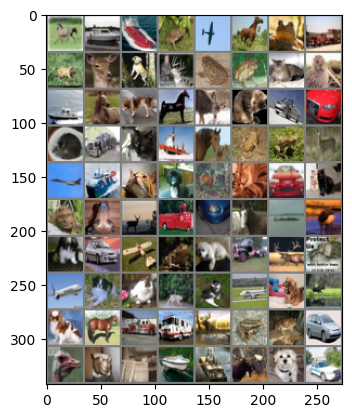

In [4]:
# 查看数据
images, labels = next(iter(train_loader))
plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5)
#plt.title(' '.join(train_set.classes[label] for label in labels))
plt.show()

<br>

## 3.  定义一个神经网络

<br>

<font color=black size=3 face=雅黑>　　为了构建神经网络，我们将使用 torch.nn 包，它是 PyTorch 的神经网络库。我们通常会将 torch.nn 包直接导入并命名为 nn。

In [5]:
import torch.nn as nn

<br>
<font color=black size=3 face=雅黑>　　PyTorch 的神经网络库包含了构建神经网络所需的所有典型组件。我们构建一个神经网络使用的最主要组件是层，所以 PyTorch 的神经网络库包含了帮助我们构造层的类。在神经网络包里有一类被称为“模块” (nn.Module) 的特殊类，它是所有神经网络模块的母类。PyTorch 中所有的神经网络层均继承了 nn.Module。    

<br>    
    
<font color=black size=3 face=雅黑>　　神经网络中的每一层都包含两个主要组成部分，第一是该层参数的集合 (weights and biases)，第二是该层进行的变换 (transformation)。其中，进行的变换主要指前向传播过程，每一个 PyTorch nn.Module 都有一个 forward() 函数来定义其前向传播。因此，当我们实现一个自定义的神经网络 (nn.Module 子类) 时，也需要编写其 forward() 函数。值得注意的是，得益于 PyTorch 的自动求导功能，我们并不需要像之前的实验一样自己编写反向传播的 backward() 函数，PyTorch 会自动帮我们完成。
    
<br>

<font color=black size=3 face=雅黑>　　总结起来，在 PyTorch 中定义神经网络包括如下几个步骤：
    
<font color=black size=3 face=雅黑>　　　1) 基于 nn.Module 创建一个类 (extend the nn.Module base class)　
    
<font color=black size=3 face=雅黑>　　　2) 在类构造函数中，将网络的层定义为类属性 (define layers as class attributes)
    
<font color=black size=3 face=雅黑>　　　3) 定义网络的前向传输计算 (implement the forward() method)

<br>

<font color=black size=3 face=雅黑>　　下面，我们就可以创建一个类来表示一个简单的神经网络。

<br>

In [6]:
class Network0(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        self.layer = None
    
    def forward(self, t):
        t = self.layer(t)
        return t

<font color=black size=3 face=雅黑>　　在这个例子中，我们扩展了 nn.Module 基类。它在构造函数中有一个虚拟层 (self.layer)，并在 forward() 函数中实现了一个虚拟的前向传播过程。forward() 接收来自神经网络输入端的张量 t，对其进行张量变换 (transformation)，并将变换后的结果返回。

<br>

<font color=black size=3 face=雅黑>　　现在，让我们用一些真正的层来替代这个虚拟层，这些层将由PyTorch 神经网络库提供。我们将建立一个卷积神经网络，包含两个卷积层和三个全连接层。其中，卷积层我们将用 torch.nn 的内建层类 nn.Conv2d 来实现，全连接层将用 nn.Linear 来实现。

    
<font color=black size=3 face=雅黑>　　nn.Conv2d 可见 PyTorch 官网：   https://pytorch.org/docs/master/generated/torch.nn.Conv2d.html#torch.nn.Conv2d
    
<font color=black size=3 face=雅黑>　　nn.Linear 可见 PyTorch 官网：
https://pytorch.org/docs/master/generated/torch.nn.Linear.html#torch.nn.Linear
    
<br>  

<font color=black size=3 face=雅黑>　　假设我们将使用 CIFAR-10 数据集，每张图片为一个 32\*32 的RGB彩色图。在即将定义的神经网络中，每个卷积层之后我们都会进行池化操作 (pooling)，池化的 kernel 大小和 stride 均取 2（即每次将对 2*2 的元素进行 max pooling）。 池化层由于不包含可训练的参数，因此不作为 Network1 的类属性（class attribute），而是会在之后写入 forward() 函数里。
    
<br>
    
<font color=black size=3 face=雅黑>　　**请大家阅读以下代码，在实验报告中：**
    
    
<font color=black size=3 face=雅黑>　　  **1) 指出各层权重的维数（卷积层：$P * D * K * K$；全连接层：$M_l * M_{l-1}$）；**
    
    
<font color=black size=3 face=雅黑>　　  **2) 指出当一张图片输入进网络后各层输入、输出值的维数；（卷积层激活值以三维张量表示（高度 * 宽度 * 深度）），全连接层激活值以一维张量表示即可（向量长度）。）**
        
<br>

In [7]:
class Network1(nn.Module): 
    def __init__(self):
        super(Network1, self).__init__() 
        self.conv1 = nn.Conv2d(in_channels=3,  # 输入通道数
                               out_channels=6,  # 输出通道数
                               kernel_size=5)  # kernel 大小 （对应四维权重张量的 dim2/dim3）
             
        ##################### please finish the code ########################

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5) # 输出通道数 12，kernel 大小 5*5
        
        self.fc1 = nn.Linear(in_features=12*5*5, out_features=120)  # 已知输入、输出激活向量的长度分别为 12*5*5 与 120
        
        self.fc2 = nn.Linear(in_features=120, out_features=60)  # 输出激活向量的长度为 60
        
        self.out = nn.Linear(in_features=60, out_features=10)  # 输出层
        
        #####################################################################
                     
        
    def forward(self, t):
        # leave it blank (we will implement the forward path later)
        
        return t

<font color=black size=3 face=雅黑>　　查看定义好的网络结构

In [8]:
network = Network1()
print(network)

Network1(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=300, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


<font color=black size=3 face=雅黑>　　查看卷积层及其参数

In [9]:
print(network.conv1)
print(network.conv2)

Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))


In [10]:
print(network.conv1.weight)  # check the weights of conv1

Parameter containing:
tensor([[[[ 9.2503e-02, -9.1250e-02,  5.1317e-03,  3.8108e-02,  1.7049e-02],
          [-4.8554e-02, -9.2318e-02, -1.0516e-01,  5.1493e-02,  1.2621e-02],
          [ 8.4417e-02, -4.1544e-02, -1.3102e-02,  1.0305e-01,  6.9333e-02],
          [-6.2342e-02,  4.9551e-02, -1.0752e-01, -1.0675e-01,  4.1148e-02],
          [-1.5096e-02,  9.3505e-02,  2.9593e-02, -6.7808e-02, -2.0331e-02]],

         [[-9.4827e-02,  5.0106e-02,  1.0308e-01,  4.6333e-03,  1.0172e-01],
          [ 1.9202e-02, -8.1845e-02, -1.0085e-01,  9.0904e-02,  8.4415e-03],
          [ 9.6715e-02, -7.7160e-02,  1.0186e-01,  5.9888e-03,  9.7880e-04],
          [-2.8259e-02,  1.5457e-02, -1.1489e-01, -9.0092e-02,  5.7821e-02],
          [ 4.5656e-02, -5.7492e-02, -4.9350e-02, -9.8322e-02, -1.8118e-02]],

         [[ 6.1745e-02,  8.6210e-02, -5.3685e-02,  6.4621e-02,  8.5780e-02],
          [-4.5460e-02,  4.2700e-02,  3.5747e-02, -1.5153e-02, -1.0371e-01],
          [-4.3955e-02, -9.6526e-02,  5.1925e-02, 

In [11]:
print(network.conv1.weight.shape)  # check the shape of conv1's weight tensor
print(network.conv1.weight[0])  # check weigth[0]
print(network.conv1.weight[0].shape)  # check the shape of weight[0]

torch.Size([6, 3, 5, 5])
tensor([[[ 0.0925, -0.0913,  0.0051,  0.0381,  0.0170],
         [-0.0486, -0.0923, -0.1052,  0.0515,  0.0126],
         [ 0.0844, -0.0415, -0.0131,  0.1031,  0.0693],
         [-0.0623,  0.0496, -0.1075, -0.1068,  0.0411],
         [-0.0151,  0.0935,  0.0296, -0.0678, -0.0203]],

        [[-0.0948,  0.0501,  0.1031,  0.0046,  0.1017],
         [ 0.0192, -0.0818, -0.1009,  0.0909,  0.0084],
         [ 0.0967, -0.0772,  0.1019,  0.0060,  0.0010],
         [-0.0283,  0.0155, -0.1149, -0.0901,  0.0578],
         [ 0.0457, -0.0575, -0.0494, -0.0983, -0.0181]],

        [[ 0.0617,  0.0862, -0.0537,  0.0646,  0.0858],
         [-0.0455,  0.0427,  0.0357, -0.0152, -0.1037],
         [-0.0440, -0.0965,  0.0519,  0.0609,  0.0971],
         [-0.0795, -0.0673,  0.0796,  0.1092,  0.0552],
         [-0.0728,  0.0403, -0.0827, -0.0529,  0.0662]]],
       grad_fn=<SelectBackward0>)
torch.Size([3, 5, 5])


<font color=black size=3 face=雅黑>　　查看全连接层及其参数

In [12]:
# weight tensor for fc layers
print(network.fc1.weight.shape)
print(network.fc1.weight[0].shape)

torch.Size([120, 300])
torch.Size([300])


<font color=black size=3 face=雅黑>　　查看整个网络的参数

In [13]:
# 方式一
for name, param in network.named_parameters():
    print(name, '\t\t', param.shape)
print("")    

#方式二
for name in network.state_dict():  # state dictionary
    print(name, '\t\t', network.state_dict()[name].shape)

conv1.weight 		 torch.Size([6, 3, 5, 5])
conv1.bias 		 torch.Size([6])
conv2.weight 		 torch.Size([12, 6, 5, 5])
conv2.bias 		 torch.Size([12])
fc1.weight 		 torch.Size([120, 300])
fc1.bias 		 torch.Size([120])
fc2.weight 		 torch.Size([60, 120])
fc2.bias 		 torch.Size([60])
out.weight 		 torch.Size([10, 60])
out.bias 		 torch.Size([10])

conv1.weight 		 torch.Size([6, 3, 5, 5])
conv1.bias 		 torch.Size([6])
conv2.weight 		 torch.Size([12, 6, 5, 5])
conv2.bias 		 torch.Size([12])
fc1.weight 		 torch.Size([120, 300])
fc1.bias 		 torch.Size([120])
fc2.weight 		 torch.Size([60, 120])
fc2.bias 		 torch.Size([60])
out.weight 		 torch.Size([10, 60])
out.bias 		 torch.Size([10])


In [14]:
# 查看 conv1 的参数
print(network.state_dict()["conv1.weight"].shape)
print(network.state_dict()["conv1.weight"])

torch.Size([6, 3, 5, 5])
tensor([[[[ 9.2503e-02, -9.1250e-02,  5.1317e-03,  3.8108e-02,  1.7049e-02],
          [-4.8554e-02, -9.2318e-02, -1.0516e-01,  5.1493e-02,  1.2621e-02],
          [ 8.4417e-02, -4.1544e-02, -1.3102e-02,  1.0305e-01,  6.9333e-02],
          [-6.2342e-02,  4.9551e-02, -1.0752e-01, -1.0675e-01,  4.1148e-02],
          [-1.5096e-02,  9.3505e-02,  2.9593e-02, -6.7808e-02, -2.0331e-02]],

         [[-9.4827e-02,  5.0106e-02,  1.0308e-01,  4.6333e-03,  1.0172e-01],
          [ 1.9202e-02, -8.1845e-02, -1.0085e-01,  9.0904e-02,  8.4415e-03],
          [ 9.6715e-02, -7.7160e-02,  1.0186e-01,  5.9888e-03,  9.7880e-04],
          [-2.8259e-02,  1.5457e-02, -1.1489e-01, -9.0092e-02,  5.7821e-02],
          [ 4.5656e-02, -5.7492e-02, -4.9350e-02, -9.8322e-02, -1.8118e-02]],

         [[ 6.1745e-02,  8.6210e-02, -5.3685e-02,  6.4621e-02,  8.5780e-02],
          [-4.5460e-02,  4.2700e-02,  3.5747e-02, -1.5153e-02, -1.0371e-01],
          [-4.3955e-02, -9.6526e-02,  5.1925e-0

<br>

<font color=black size=3 face=雅黑>　　网络的卷积层和全连接层定义好了。现在，让我们来实现 forward() 函数。
    
<font color=black size=3 face=雅黑>　　神经网络 forward() 函数的编写通常需要使用来自 nn.functional 的函数，这个包为我们提供了许多实现前向传播时需要的神经网络操作，例如激活函数 ReLU 和池化操作 Max Pooling。值得注意的是，虽然我们常称它们为“激活层”和“池化层”，但实际上它们都是在执行某种操作，并不包含可训练的参数。因此，它们在 PyTorch 中并没有被作为层来处理，也没有继承 nn.Module 基类，而是包含在 nn.functional 中。
    
<br>

In [15]:
import torch.nn.functional as F

In [16]:
class Network2(nn.Module): # 重新定义一个类 Network2
    def __init__(self):
        super(Network2, self).__init__()        
        self.conv1 = nn.Conv2d(in_channels=3,  # 输入通道数
                               out_channels=6,  # 输出通道数
                               kernel_size=5)  # kernel 大小 （对应四维权重张量的 dim2/dim3）
             
        ##################### please finish the code ########################

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5) # 输出通道数 12，kernel 大小 5*5
        
        self.fc1 = nn.Linear(in_features=12*5*5, out_features=120)  # 已知输入、输出激活向量的长度分别为 12*5*5 与 120
        
        self.fc2 = nn.Linear(in_features=120, out_features=60)  # 已知输入、输出激活向量的长度分别为 120 与 60
        
        self.out = nn.Linear(in_features=60, out_features=10)  # 输出层
        
        #####################################################################
        
        
    def forward(self, t):
        
        # conv1
        t = self.conv1(t)
        t = F.relu(t)  # 这里我们用到了 nn.functional 包中的激活函数 relu
        t = F.max_pool2d(t, kernel_size=2, stride=2)  # 这里我们用到了 nn.functional 包中的池化函数 max_pool2d （max pooling）
        
        # conv2
        t = self.conv2(t)
        t = F.relu(t)
        t = F.max_pool2d(t, kernel_size=2, stride=2)
        
        # 最后一个卷积层的输出在进入全连接层之前，要对激活值的维度进行变换，变换后的张量
        # 是二维张量，其中 dim0 对应该批次中的不同样本，dim1 对应每个样本的输入激活向量。
        t = t.reshape(batch_size, -1)   

        ##################### please finish the code ########################

        # 完成剩余的代码(完成fc1、fc2、out层的相关计算)
        t = self.fc1(t)
        t = F.relu(t)
        t = self.fc2(t)
        t = F.relu(t)
        t = self.out(t)
        
        ################################ end ################################

        return t

<br>

<font color=black size=3 face=雅黑>　　在 PyTorch 中，当我们直接调用对象名称 conv1/conv2/fc1/fc2 并将输入 t 传递给它时，对应的 forward() 函数将被调用。因此，在上述代码中， 我们直接将输入 t 传递给了 conv1，而没有使用 t = self.conv1.forward(t)。
    
<br>
    
<font color=black size=3 face=雅黑>　　到这里，我们已经完成了神经网络的构建。下一步，我们将训练这个神经网络来处理手写字体识别任务。
    

<font color=black size=3 face=雅黑>　　在开始训练之前，我们先来看一下这个神经网络的正向传播过程。


In [17]:
# 关掉 PyTorch 的自动求导功能
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [18]:
network = Network2()

# 我们取一批图片给 network
batch = next(iter(train_loader))  # DataLoader object: train_loader
images, labels = batch
print(images.shape)  # rank-4 tensor
print(labels.shape)

output = network(images)

torch.Size([80, 3, 32, 32])
torch.Size([80])


In [19]:
# 查看 output 形状: rank-2 tensor
output.shape

torch.Size([80, 10])

In [20]:
# F.softmax(t, dim=1）会为每个预测类返回一个概率值，这些概率值之和等于1。我们没有将这一步放在 Network2.forward()
# 中来做，是因为我们在训练网络将使用交叉熵损失函数 nn.CrossEntropyLoss，它会在其输入上隐式的执行一个 Softmax 操作。
output_prob = F.softmax(output, dim=1)

# 在之前的练习中我们已经知道，torch.max(t, dim=1) 函数会返回两个 tensor，第一个 tensor 是每行的最大值；第二个
# tensor是每行最大值的索引，反映了批处理中每个图像的预测标签。
scores, predict_class = torch.max(output_prob, dim=1)

print("scores: \n", scores)
print("predicted labels: \n", predict_class)

scores: 
 tensor([0.1105, 0.1105, 0.1107, 0.1104, 0.1103, 0.1104, 0.1106, 0.1104, 0.1114,
        0.1111, 0.1104, 0.1104, 0.1102, 0.1105, 0.1112, 0.1106, 0.1107, 0.1110,
        0.1109, 0.1102, 0.1111, 0.1105, 0.1106, 0.1106, 0.1104, 0.1105, 0.1103,
        0.1104, 0.1103, 0.1101, 0.1104, 0.1100, 0.1109, 0.1106, 0.1106, 0.1104,
        0.1109, 0.1104, 0.1104, 0.1107, 0.1107, 0.1103, 0.1106, 0.1105, 0.1112,
        0.1107, 0.1108, 0.1108, 0.1106, 0.1106, 0.1104, 0.1105, 0.1104, 0.1107,
        0.1105, 0.1104, 0.1106, 0.1107, 0.1104, 0.1104, 0.1102, 0.1106, 0.1110,
        0.1103, 0.1101, 0.1108, 0.1105, 0.1104, 0.1109, 0.1106, 0.1106, 0.1102,
        0.1107, 0.1105, 0.1107, 0.1106, 0.1107, 0.1104, 0.1104, 0.1104])
predicted labels: 
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 

In [21]:
# 查看实际标签
print("actual labels: \n", labels)

actual labels: 
 tensor([1, 9, 8, 4, 5, 6, 7, 9, 1, 1, 2, 0, 0, 3, 3, 3, 0, 2, 1, 7, 8, 5, 0, 7,
        9, 6, 6, 4, 1, 3, 8, 1, 4, 2, 4, 9, 4, 8, 8, 9, 0, 6, 1, 4, 8, 7, 6, 8,
        1, 2, 5, 0, 2, 6, 9, 9, 6, 0, 0, 1, 3, 2, 7, 8, 2, 9, 4, 7, 5, 8, 7, 8,
        5, 3, 0, 3, 0, 7, 7, 3])


In [22]:
# 计算这一批样本识别的“准确率”
correct_predictions = (predict_class == labels).sum().item()  # 识别正确的次数
print("correct predictions: ", correct_predictions)
print("\"accuracy\": ", correct_predictions/len(labels)*100, "%") 

correct predictions:  10
"accuracy":  12.5 %


In [23]:
# 现在我们可以将自动求导功能打开，为训练做好准备
torch.set_grad_enabled(True)

torch.autograd.grad_mode.set_grad_enabled(mode=True)

<br>

## 4.  训练神经网络

<br>

<font color=black size=3 face=雅黑>　　在这一部分中，我们将在数据集 CIFAR-10 上训练构建好的神经网络。
    
<br>

<font color=black size=3 face=雅黑>　　在定义完神经网络之后，我们还需要在 torch.nn 包中选择合适的损失函数 (loss function) 来评估网络输出与理想值之间的差别。常用的损失函数都已经定义在了 torch.nn 中，比如均方误差 (nn.MSELoss)、多分类的交叉熵 (nn.CrossEntropyLoss) 及二分类的交叉熵 (nn.BCELoss)，等等。由于我们将进行十分类任务，本次实验我们将选用交叉熵损失函数。
    
<font color=black size=3 face=雅黑>　　一个损失函数需要一对输入：模型的实际输出和目标输出。基于此，损失函数将计算一个值 (loss) 来评估实际输出距离目标输出有多远。

In [24]:
loss_func = nn.CrossEntropyLoss()

<font color=black size=3 face=雅黑>　　除了损失函数以外，我们还需要一个能更直观的反映分类准确性的函数，方便我们了解训练的情况。请大家阅读并理解以下 get_num_correct 的代码每一步在做什么。

In [25]:
def get_num_correct(preds, labels):  # get the number of correct times
    return preds.argmax(dim=1).eq(labels).sum().item()

<font color=black size=3 face=雅黑>　　在深度学习的训练过程中，我们需要通过不断调整参数使得损失最小化。优化算法就是一种调整模型参数更新的策略。在这里，我们需要用到一个新的包：torch.optim，其中“optim”是“optimizer”的缩写，它包含了多种常用的优化算法。


In [26]:
import torch.optim as optim

<font color=black size=3 face=雅黑>　　本次实验我们将使用随机梯度下降法 (SGD) 来对网络进行优化。

In [27]:
optimizer = optim.SGD(network.parameters(), lr=1)  # lr: 学习率

<font color=black size=3 face=雅黑>　　现在我们已经做好了训练的前期准备。在开始大规模的训练前，我们先来观察一个批次 (batch) 的图片是如何被训练的。

<font color=black size=3 face=雅黑>　　首先，我们取出一个 batch 的样本，传递给 network，并计算损失。

In [28]:
batch = next(iter(train_loader))
images, labels = batch

preds = network(images)
loss = loss_func(preds, labels)
loss.item()

2.305384397506714

<font color=black size=3 face=雅黑>　　现在我们有了 loss，下一步可以计算偏导 (gradients)。为了计算偏导，我们会在损失张量上调用反向函数 loss.backward()，PyTorch 会自动帮我们做相关的计算。

In [29]:
loss.backward()

<font color=black size=3 face=雅黑>　　我们可以看看100张图片中分类正确的次数：

In [30]:
get_num_correct(preds, labels) 

7

<font color=black size=3 face=雅黑>　　下一步是使用这些偏导来更新网络的权重。

In [31]:
optimizer.step()  # 更新参数的方法

<font color=black size=3 face=雅黑>　　我们将同一批样本再次传递给更新后的神经网络，看看 loss 和分类正确的次数有什么变化。

In [32]:
preds = network(images)
loss = loss_func(preds, labels)
print("loss: ", loss.item())
print("number of correct times: ", get_num_correct(preds, labels))

loss:  2.2959370613098145
number of correct times:  7


<font color=black size=3 face=雅黑>　　可以看到 loss 有些微的下降，说明我们确实是在朝着损失减小的方向调整参数。下面我们来完整实现整个训练过程。
    
<font color=black size=3 face=雅黑>　　**请大家补全以下代码，在实验报告中展示相关代码并做出说明，训练结果请截图保存。**    
    
<br>

In [33]:
total_epochs = 10

for epoch in range(total_epochs):  # 训练周期

    total_loss = 0
    total_train_correct = 0

    for batch in train_loader:  # get a batch from the dataloader
        
        ##################### please finish the code ########################
        
        # 读取样本数据，完成正向传播，计算损失
        images, labels = batch    
        preds = network(images)
        loss = loss_func(preds, labels)    
        
        ################################ end ################################
        
        # 下面这行非常重要，它使得优化器 (optimizer) 将权重的偏导重新归零；
        # 如果不归零，那么在反向传播时，计算出来的偏导会累加在原先的偏导上，
        # 造成错误。
        optimizer.zero_grad()
                
        ##################### please finish the code ########################
        
        # 完成反向传播，更新参数：   
        loss.backward()  # 反向传播 （一行代码）
        
        optimizer.step()  # 更新参数 （一行代码）        

        
        # 累计计算本 epoch 总损失
        total_loss += loss.item()
        
        # 累计计算本 epoch 分类正确的总样本数
        total_train_correct += get_num_correct(preds, labels)        
        
        ################################ end ################################
    
    print("epoch:", epoch, 
          "correct times:", total_train_correct,
          f"training accuracy:", "%.3f" %(total_train_correct/len(train_set)*100), "%", 
          "total_loss:", "%.3f" %total_loss)

epoch: 0 correct times: 9253 training accuracy: 18.506 % total_loss: 1336.658
epoch: 1 correct times: 14564 training accuracy: 29.128 % total_loss: 1185.557
epoch: 2 correct times: 15598 training accuracy: 31.196 % total_loss: 1148.035
epoch: 3 correct times: 16262 training accuracy: 32.524 % total_loss: 1132.955
epoch: 4 correct times: 16140 training accuracy: 32.280 % total_loss: 1131.230
epoch: 5 correct times: 16193 training accuracy: 32.386 % total_loss: 1133.980
epoch: 6 correct times: 16645 training accuracy: 33.290 % total_loss: 1117.225
epoch: 7 correct times: 16709 training accuracy: 33.418 % total_loss: 1115.014
epoch: 8 correct times: 16985 training accuracy: 33.970 % total_loss: 1114.284
epoch: 9 correct times: 17074 training accuracy: 34.148 % total_loss: 1107.073


<font color=black size=3 face=雅黑>　　训练结果看上去不错，让我们在测试集上看看准确率如何。
    
<font color=black size=3 face=雅黑>　　**请将测试结果保存，并展示在实验报告中。**    
 

In [34]:
total_test_correct = 0
total_loss = 0

for batch in test_loader:  # get a batch from the dataloader
    images, labels = batch
    preds = network(images)
    loss = loss_func(preds, labels)

    total_loss += loss
    total_test_correct += get_num_correct(preds, labels)
    
print("correct times:", total_test_correct, 
      f"test accuracy:", "%.3f" %(total_test_correct/len(test_set)*100), "%",
      "total_loss:", "%.3f" %total_loss)

correct times: 3328 test accuracy: 33.280 % total_loss: 228.358


C:\Users\trash\AppData\Local\Temp\ipykernel_34184\997130808.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  "total_loss:", "%.3f" %total_loss)


<br>

# 5.  实验报告

<br>

<font color=black size=3 face=雅黑>请同学们在实验报告中完成如下内容（【附加题】选做）：
          
<font color=black size=3 face=雅黑>----------------------------------------------------------------
    
<font color=black size=3 face=雅黑>(1) 完成实验指导书“1_python_cnn”，结果截图保存，并根据自己的理解，对填补的各个模块代码进行简要说明。
  
<font color=black size=3 face=雅黑>----------------------------------------------------------------

<font color=black size=3 face=雅黑>(2) 回答以上关于神经网络结构的问题（已加粗），即：   
    
<font color=black size=3 face=雅黑>　-　指出各层权重的维数（卷积层：$P * D * K * K$；全连接层：$M_l * M_{l-1}$）；    
    
<font color=black size=3 face=雅黑>　-　指出当一张图片输入进网络后各层输入、输出值的维数；（卷积层激活值以三维张量表示（高度 * 宽度 * 深度）），全连接层激活值以一维张量表示即可（向量长度）。）

<font color=black size=3 face=雅黑>----------------------------------------------------------------

<font color=black size=3 face=雅黑>(3) 代码修改：

<font color=black size=3 face=雅黑>　-  其余设置不变，将学习率（Ctrl+F 搜索'lr'即可找到学习率，默认值为0.1）调整为0.01、1.0，分别观察结果并简要解释。
     
<font color=black size=3 face=雅黑>----------------------------------------------------------------

<font color=black size=3 face=雅黑>(4) 扩展思考【附加题】：

<font color=black size=3 face=雅黑>　-　如果采用MNIST数据集（数据集细节鼓励大家上网/利用AI工具查取），请问上述哪些代码块要做相应修改？（描述即可）

<br>

<font color=black size=3 face=雅黑>----------------------------------------------------------------

<font color=black size=3 face=雅黑>如果大家在实验中进行了其他探索和尝试，也欢迎加在实验报告中。

<br>